In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
# Now let use see why linear regression fails for Logisic REGERESSION to begin with

In [22]:
# 1. Create dataset
df = pd.DataFrame({
    'size':[1,2,3,5,6,8],
    'malignant': [0, 0, 0, 1, 1, 1]
})

In [23]:
# 2. Fit Linear Regression
X = df[['size']]
y = df['malignant']
model = LinearRegression()
model.fit(X, y)

# 3. Add predictions and threshold outputs to DataFrame
df['y_hat'] = model.predict(X)
df['prediction'] = (df['y_hat'] >= 0.5).astype(int)


df


,size,malignant,y_hat,prediction
0,1,0,-0.090909,0
1,2,0,0.095694,0
2,3,0,0.282297,0
3,5,1,0.655502,1
4,6,1,0.842105,1
5,8,1,1.215311,1


In [24]:
# 4. Separate classes for plotting
benign = df[df['malignant'] == 0]
malignant = df[df['malignant'] == 1]

c:\Users\hp\Desktop\ML\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


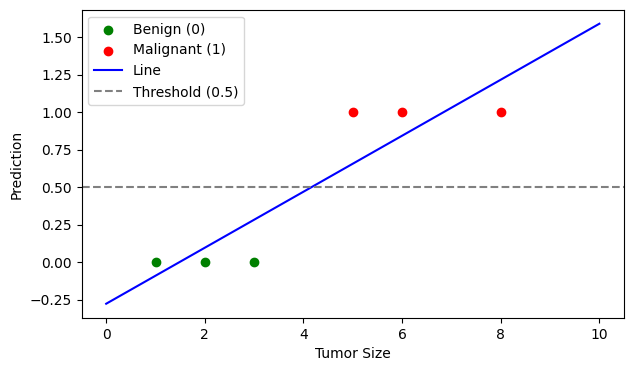

In [25]:
# 5. Simple Plot
plt.figure(figsize=(7, 4))

# Plot different classes with colors
plt.scatter(benign['size'], benign['malignant'], color='green', label='Benign (0)')
plt.scatter(malignant['size'], malignant['malignant'], color='red', label='Malignant (1)')

# Generate points to draw the regression line
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = model.predict(x_line)

# Plot regression line and 0.5 threshold
plt.plot(x_line, y_line, color='blue', label='Line')
plt.axhline(0.5, color='gray', linestyle='--', label='Threshold (0.5)')

# Layout details
plt.xlabel('Tumor Size')
plt.ylabel('Prediction')
plt.legend()
plt.show()